#Task 3. Audio Similarity Using Pretrained Embeddings

Measure the similarity between different audio clips using embeddings extracted from a pretrained audio model.

###Suggested Datasets

• speech_commands  |  TensorFlow Datasets

###Tasks

- Load multiple audio clips from the selected dataset.

- Extract embeddings using a pretrained audio model such as YAMNet, OpenL3, CLAP or Wav2Vec2.

- Compute pairwise similarity and distance scores.

- Visualize the relationships using a similarity heatmap and distance matrix.

In [4]:
#import req libs
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

import librosa
import librosa.display

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

In [12]:
import os

classes = [
    "yes",
    "no",
    "up",
    "down",
    "go"
]

audio_signals = []
labels = []

for c in classes:

    folder = os.path.join("/content", c)

    wav_file = sorted(os.listdir(folder))[0]

    path = os.path.join(folder, wav_file)

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    audio_signals.append(audio)

    labels.append(c)

print("Loaded Classes:")
print(labels)

Loaded Classes:
['yes', 'no', 'up', 'down', 'go']


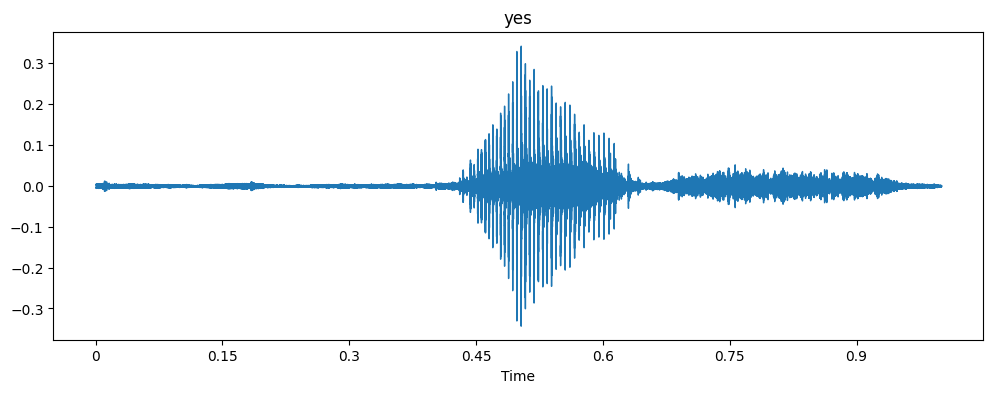

In [13]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio_signals[0],
    sr=16000
)

plt.title(labels[0])

plt.show()

## Load Pretrained YAMNet Model

YAMNet is a pretrained deep learning model developed by Google for audio event classification. It converts audio clips into high-dimensional embeddings that can be used to measure similarity between different audio samples.

In [14]:
yamnet_model = hub.load(
    "https://tfhub.dev/google/yamnet/1"
)

print("YAMNet loaded successfully.")

YAMNet loaded successfully.


## Extract Audio Embeddings

Each audio clip is passed through the pretrained YAMNet model to generate an embedding vector. These embeddings represent the semantic characteristics of the audio and are later used for similarity comparison.

In [15]:
embeddings = []

for audio in audio_signals:

    scores, embedding, spectrogram = yamnet_model(audio)

    embedding = tf.reduce_mean(
        embedding,
        axis=0
    )

    embeddings.append(
        embedding.numpy()
    )

embeddings = np.array(embeddings)

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (5, 1024)


## Compute Cosine Similarity

Cosine similarity measures how similar two embedding vectors are. A value close to 1 indicates high similarity, while values closer to 0 indicate lower similarity.

In [16]:
# Compute Cosine Similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[1.         0.610507   0.69407684 0.78784674 0.8148561 ]
 [0.610507   1.0000002  0.6226275  0.6153586  0.5157823 ]
 [0.69407684 0.6226275  0.99999994 0.65441    0.65197766]
 [0.78784674 0.6153586  0.65441    0.9999999  0.6585608 ]
 [0.8148561  0.5157823  0.65197766 0.6585608  0.99999994]]


## Similarity Heatmap

The similarity heatmap visualizes the cosine similarity between all pairs of audio clips extracted using the pretrained YAMNet embeddings.

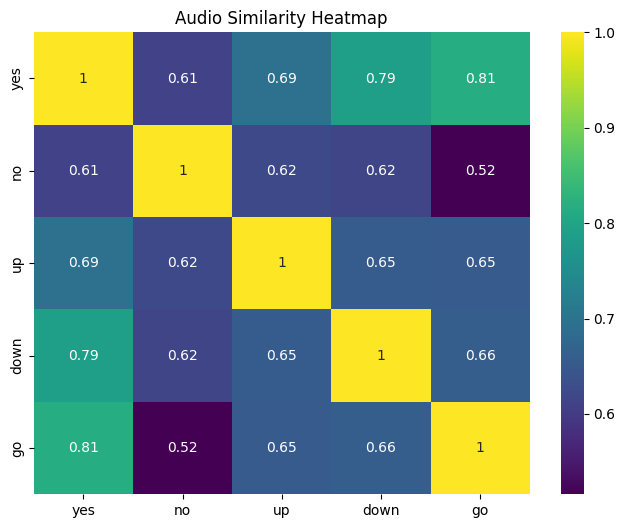

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Audio Similarity Heatmap")

plt.show()

## Distance Matrix

Euclidean distance is computed between embedding vectors. Smaller values indicate that two audio clips are more similar.

In [18]:
distance_matrix = cdist(
    embeddings,
    embeddings,
    metric="euclidean"
)

print(distance_matrix)

[[0.         4.85579664 4.8769289  3.61688124 5.15234709]
 [4.85579664 0.         5.20297849 4.41247951 7.42715288]
 [4.8769289  5.20297849 0.         4.99052532 6.61286357]
 [3.61688124 4.41247951 4.99052532 0.         6.53858118]
 [5.15234709 7.42715288 6.61286357 6.53858118 0.        ]]


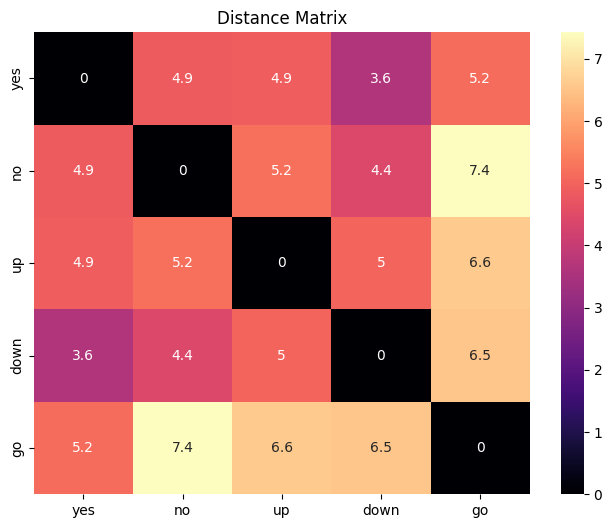

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_matrix,
    annot=True,
    cmap="magma",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Distance Matrix")

plt.show()

## Final Observation

In this task, multiple speech audio clips were loaded from the Google Speech Commands dataset and processed using the pretrained YAMNet model. Each audio clip was converted into a high-dimensional embedding vector representing its acoustic characteristics.

Cosine similarity was computed to measure how similar the audio clips are, while Euclidean distance was used to measure the differences between their embedding vectors. The similarity heatmap provides an intuitive visualization of the relationships between different speech commands, whereas the distance matrix highlights the relative separation between the extracted embeddings.

This experiment demonstrates that pretrained audio embedding models can effectively represent speech signals for similarity analysis without requiring additional model training or fine-tuning.